<a href="https://www.kaggle.com/code/avikdas567/multimodal-multi-plane-2-5d-cnn-knee-mri-detection?scriptVersionId=340643159" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Multimodal Multi-Plane 2.5D Convolutional Network and Multilingual Weakly Supervised Learning for RSNA Knee Abnormality Detection

## Overview

Knee magnetic resonance imaging (MRI) is the primary non-invasive diagnostic modality for evaluating joint articular structures, soft tissue ligaments, meniscal integrity, and subchondral bone pathologies. In this competition, models are developed to classify twelve distinct pathological findings across multi-sequence, multi-plane volumetric knee MRI examinations.

## Mathematical Problem Formulation

Let $\mathcal{X}_i = \{ \mathbf{V}_{i, \text{Sagittal}}, \mathbf{V}_{i, \text{Coronal}}, \mathbf{V}_{i, \text{Axial}} \}$ denote the multi-planar volumetric MRI sequences associated with study $i \in \{1, 2, \dots, N\}$. Each study is evaluated against $C = 12$ binary target pathologies:
$$\mathbf{y}_i = [y_{i,1}, y_{i,2}, \dots, y_{i,12}]^T \in \{0, 1\}^{12}$$

The objective is to estimate a parameterized mapping function $f_{\theta}: \mathcal{X}_i \rightarrow [0, 1]^{12}$ that maximizes the Macro-Averaged Area Under the Receiver Operating Characteristic Curve (Macro-AUC ROC) across all twelve targets:

$$\text{Macro-AUC} = \frac{1}{C} \sum_{c=1}^{C} \text{AUC}_c$$

where the per-class AUC for target $c$ is defined as:

$$\text{AUC}_c = \frac{1}{|\mathcal{P}_c| |\mathcal{N}_c|} \sum_{i \in \mathcal{P}_c} \sum_{j \in \mathcal{N}_c} \mathbb{I}\left(f_{c}(\mathcal{X}_i) > f_{c}(\mathcal{X}_j)\right)$$

Here, $\mathcal{P}_c = \{i \mid y_{i,c} = 1\}$ and $\mathcal{N}_c = \{j \mid y_{j,c} = 0\}$ represent the positive and negative patient sets for condition $c$, and $\mathbb{I}(\cdot)$ is the indicator function.

## Target Pathology Framework

The twelve clinical target variables encompass distinct structural and inflammatory knee conditions:
1. **ACL**: Anterior Cruciate Ligament Injury ($c=1$)
2. **MCL**: Medial Collateral Ligament Injury ($c=2$)
3. **Medial Meniscus**: Medial Meniscal Tear or Degeneration ($c=3$)
4. **Lateral Meniscus**: Lateral Meniscal Tear or Degeneration ($c=4$)
5. **Medial OA**: Osteoarthritis of Medial Tibiofemoral Compartment ($c=5$)
6. **Lateral OA**: Osteoarthritis of Lateral Tibiofemoral Compartment ($c=6$)
7. **PF OA**: Patellofemoral Osteoarthritis ($c=7$)
8. **Effusion**: Intra-articular Joint Effusion ($c=8$)
9. **Synovitis**: Synovial Membrane Inflammation ($c=9$)
10. **Baker's**: Popliteal / Baker's Cyst ($c=10$)
11. **Contusion**: Subchondral Bone Marrow Edema / Bruise ($c=11$)
12. **Fracture**: Cortical or Trabecular Bone Fracture ($c=12$)

## Multimodal Weak Supervision Strategy

Only 58 of the 4,407 training studies possess explicit gold-standard binary labels. The remaining 4,349 studies contain unlabelled target attributes paired with free-text radiology reports in multiple languages (English, Spanish, German, French, Greek, Bulgarian, Turkish). A multilingual natural language processing (NLP) parser extracts clinical diagnostic findings directly from these 4,349 free-text reports, generating full weak supervision labels for the training set. A multi-plane 2.5D deep convolutional model with slice-attention pooling is then trained on the expanded dataset.


In [1]:
import os
import sys
import re
import gc
import time
import math
import random
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import pydicom
from PIL import Image
import cv2
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedGroupKFold

# Configure System Environment
warnings.filterwarnings('ignore')
pio.renderers.default = 'iframe'

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Verify GPU Hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"System Computation Device: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"GPU Count: {torch.cuda.device_count()}")


System Computation Device: cuda
GPU Model: Tesla T4
GPU Count: 2


# Hyperparameter & Path Configuration

The `Config` class establishes centralized system parameters, directory paths, model input dimensions, slice sampling rates, and multi-label targets.


In [2]:
class Config:
    # Directory Structure
    BASE_DIR = Path("/kaggle/input/competitions/rsna-knee-abnormality-detection")
    TRAIN_CSV = BASE_DIR / "train.csv"
    TRAIN_SERIES_CSV = BASE_DIR / "train_series.csv"
    TEST_CSV = BASE_DIR / "test.csv"
    TEST_SERIES_CSV = BASE_DIR / "test_series.csv"
    SAMPLE_SUB_CSV = BASE_DIR / "sample_submission.csv"
    
    TRAIN_SERIES_DIR = BASE_DIR / "train_series"
    TEST_SERIES_DIR = BASE_DIR / "test_series"
    
    # Target Definitions
    TARGET_COLS = [
        'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus',
        'Medial OA', 'Lateral OA', 'PF OA', 'Effusion',
        'Synovitis', "Baker's", 'Contusion', 'Fracture'
    ]
    NUM_CLASSES = 12
    
    # Model & Preprocessing Parameters
    IMAGE_SIZE = (224, 224)
    SLICES_PER_VIEW = 5  # Equidistant slices extracted per anatomical plane
    BATCH_SIZE = 8
    NUM_WORKERS = 2
    EPOCHS = 5
    LEARNING_RATE = 2e-4
    WEIGHT_DECAY = 1e-4
    SEED = 42
    
    # Output File
    OUTPUT_SUBMISSION = "submission.csv"

config = Config()
print("Configuration parameters loaded successfully.")


Configuration parameters loaded successfully.


# Exploratory Data Analysis & Metadata Validation

Metadata files are loaded and inspected to characterize label distribution, report length metrics, language diversity, and MRI series plane frequency.


In [3]:
train_df = pd.read_csv(config.TRAIN_CSV)
train_series_df = pd.read_csv(config.TRAIN_SERIES_CSV)
test_df = pd.read_csv(config.TEST_CSV)
test_series_df = pd.read_csv(config.TEST_SERIES_CSV)
sample_sub_df = pd.read_csv(config.SAMPLE_SUB_CSV)

print(f"train.csv shape: {train_df.shape}")
print(f"train_series.csv shape: {train_series_df.shape}")
print(f"test.csv shape: {test_df.shape}")
print(f"test_series.csv shape: {test_series_df.shape}")
print(f"sample_submission.csv shape: {sample_sub_df.shape}")

# Quantitative missing value assessment in train.csv
labeled_count = train_df[config.TARGET_COLS[0]].notnull().sum()
unlabeled_count = len(train_df) - labeled_count
print(f"Gold-Standard Labeled Studies: {labeled_count} ({labeled_count/len(train_df)*100:.2f}%)")
print(f"Unlabeled Studies with Text Reports: {unlabeled_count} ({unlabeled_count/len(train_df)*100:.2f}%)")


train.csv shape: (4407, 14)
train_series.csv shape: (24371, 5)
test.csv shape: (3, 1)
test_series.csv shape: (15, 5)
sample_submission.csv shape: (3, 13)
Gold-Standard Labeled Studies: 58 (1.32%)
Unlabeled Studies with Text Reports: 4349 (98.68%)


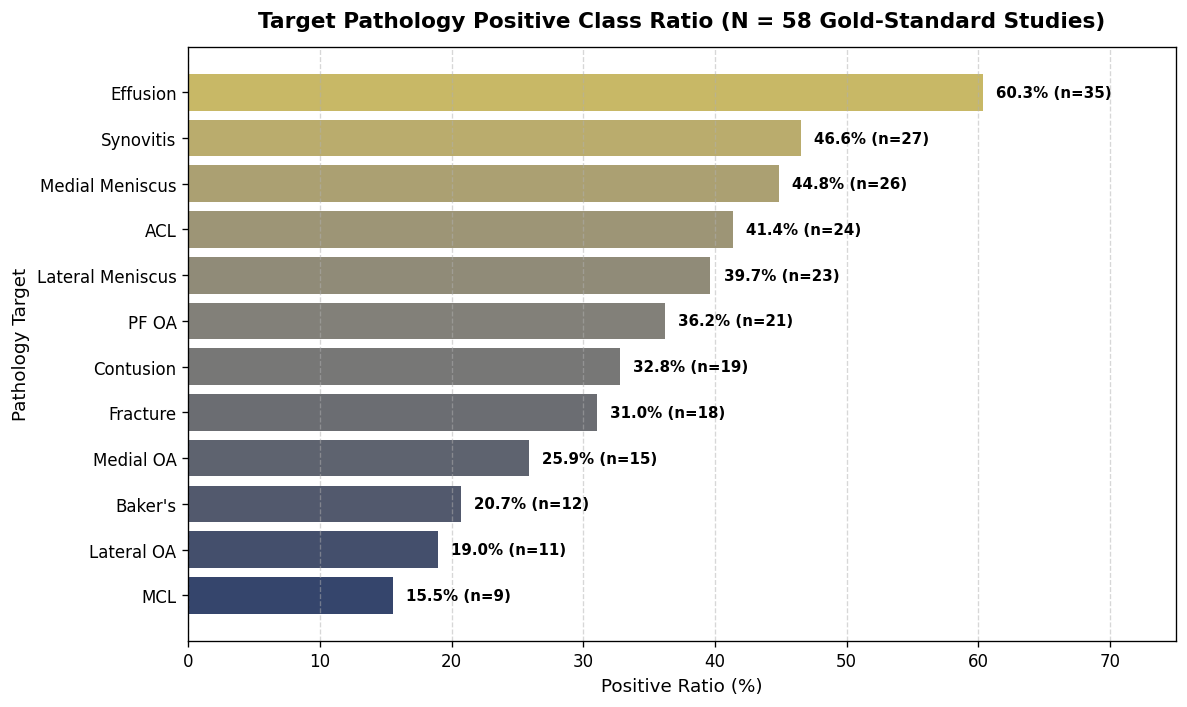

In [4]:
# Visualization 1: Target Prevalence on Gold-Standard 58 Labeled Studies
labeled_df = train_df.dropna(subset=[config.TARGET_COLS[0]])
pos_counts = labeled_df[config.TARGET_COLS].sum().sort_values(ascending=True)
pos_pct = (pos_counts / len(labeled_df)) * 100

plt.figure(figsize=(10, 6), dpi=120)
bars = plt.barh(pos_counts.index, pos_pct.values, color=plt.cm.cividis(np.linspace(0.2, 0.8, len(pos_counts))))
plt.title("Target Pathology Positive Class Ratio (N = 58 Gold-Standard Studies)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Positive Ratio (%)", fontsize=11)
plt.ylabel("Pathology Target", fontsize=11)
plt.xlim(0, 75)
plt.grid(axis='x', linestyle='--', alpha=0.5)

for bar, pct, cnt in zip(bars, pos_pct.values, pos_counts.values):
    plt.text(pct + 1, bar.get_y() + bar.get_height()/2, f"{pct:.1f}% (n={int(cnt)})", va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


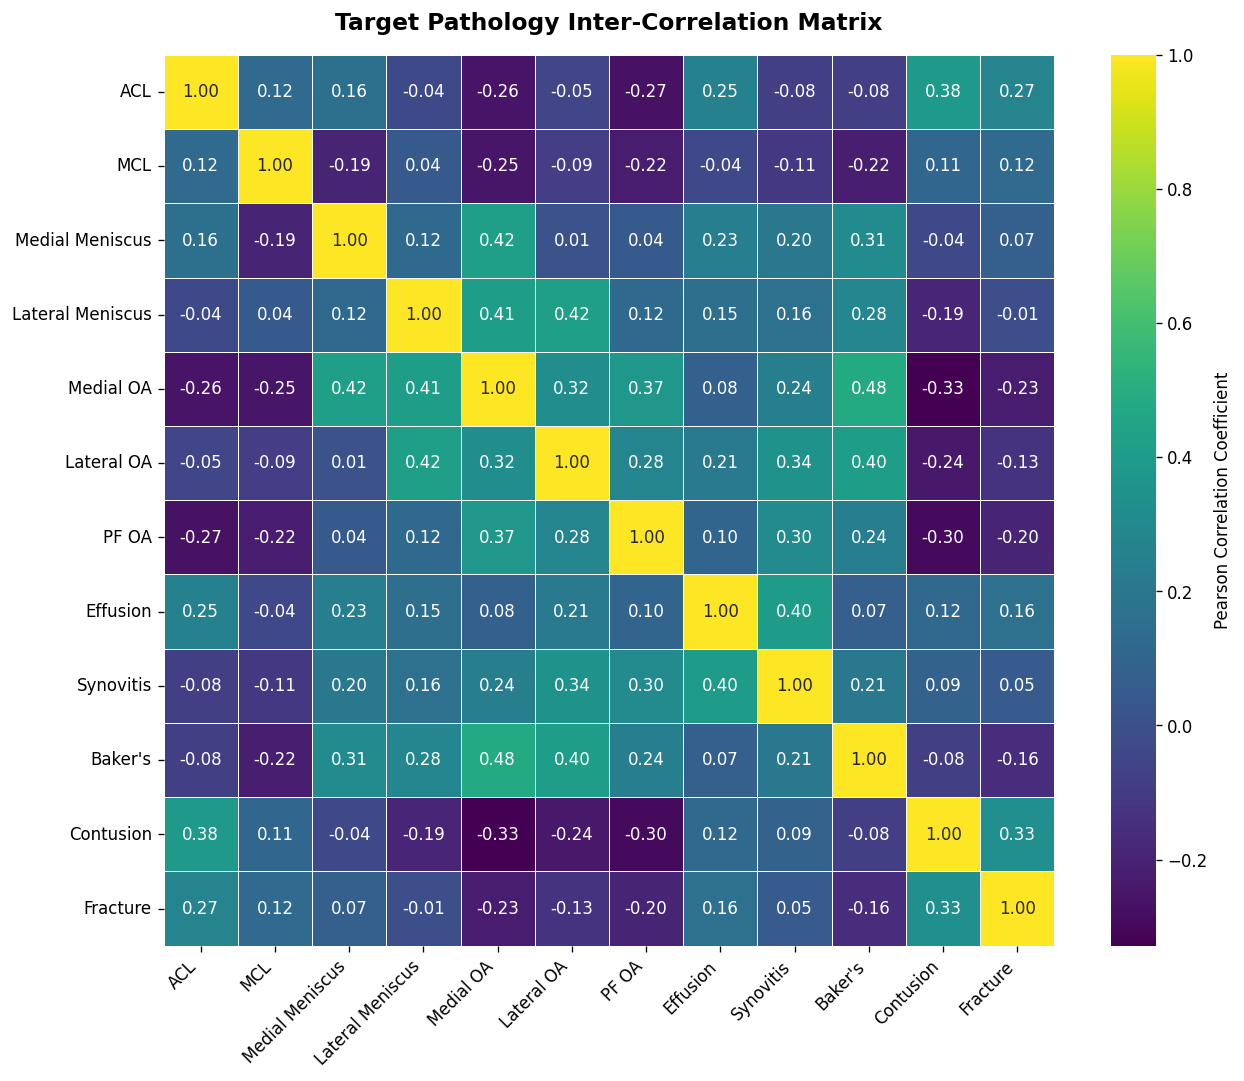

In [5]:
# Visualization 2: Target Co-Occurrence Correlation Matrix
corr_matrix = labeled_df[config.TARGET_COLS].corr()

plt.figure(figsize=(11, 9), dpi=120)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="viridis", cbar_kws={'label': 'Pearson Correlation Coefficient'},
            linewidths=0.5, linecolor='white', square=True)
plt.title("Target Pathology Inter-Correlation Matrix", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


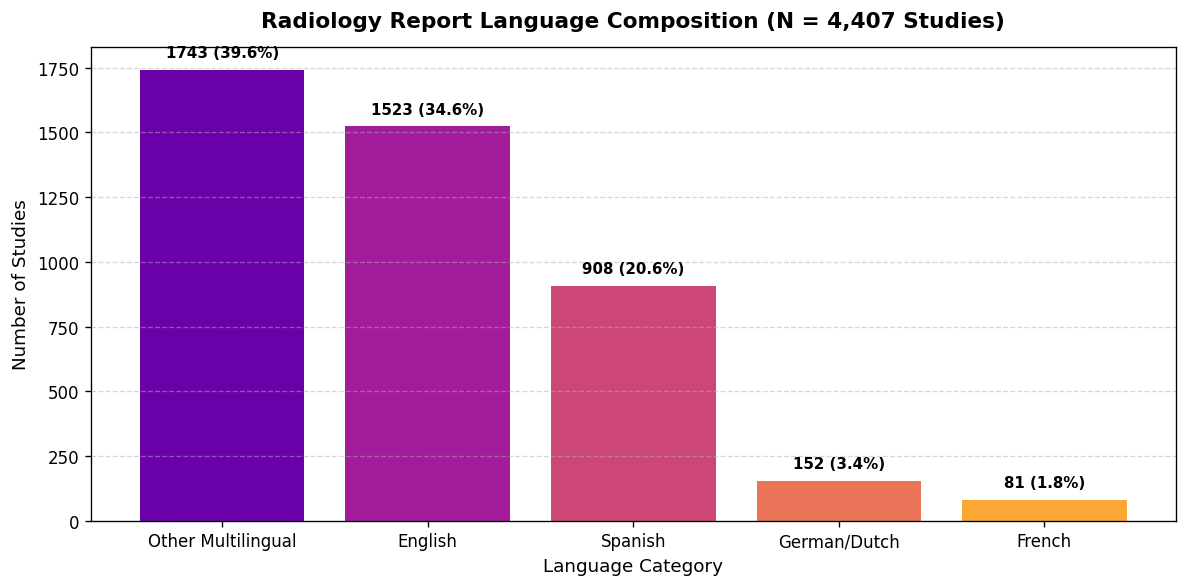

In [6]:
# Visualization 3: Report Text Length & Linguistic Analysis
train_df['report_char_len'] = train_df['Report'].astype(str).apply(len)
train_df['report_word_len'] = train_df['Report'].astype(str).apply(lambda x: len(x.split()))

def classify_language(text):
    text_lower = str(text).lower()
    if any(k in text_lower for k in ['técnica:', 'impresión:', 'hallazgos:', 'rotura', 'derrame', 'menisco']):
        return 'Spanish'
    elif any(k in text_lower for k in ['befunde:', 'klinische', 'gewogen', 'beoordeling:']):
        return 'German/Dutch'
    elif any(k in text_lower for k in ['constatations:', 'épanchement', 'ménisque', 'aucun']):
        return 'French'
    elif any(k in text_lower for k in ['impression:', 'findings:', 'meniscus', 'effusion', 'intact', 'tear']):
        return 'English'
    else:
        return 'Other Multilingual'

train_df['language'] = train_df['Report'].apply(classify_language)

plt.figure(figsize=(10, 5), dpi=120)
lang_counts = train_df['language'].value_counts()
plt.bar(lang_counts.index, lang_counts.values, color=plt.cm.plasma(np.linspace(0.2, 0.8, len(lang_counts))))
plt.title("Radiology Report Language Composition (N = 4,407 Studies)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Language Category", fontsize=11)
plt.ylabel("Number of Studies", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(lang_counts.values):
    plt.text(i, v + 50, f"{v} ({v/len(train_df)*100:.1f}%)", ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


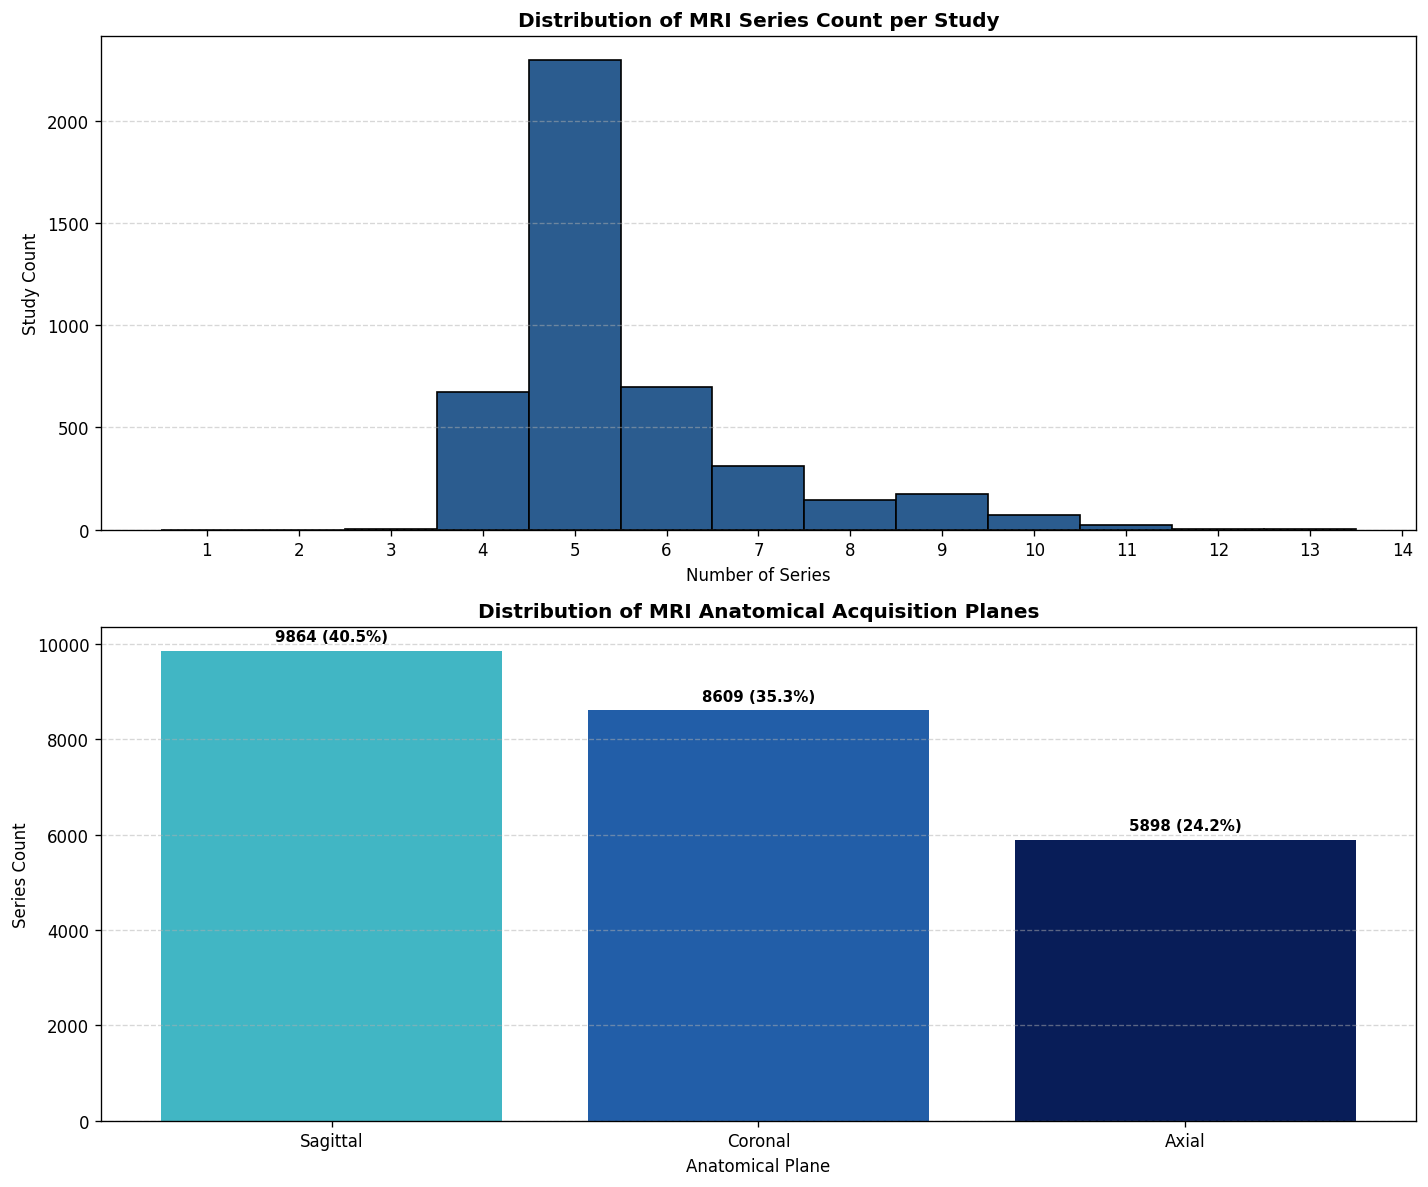

In [7]:
# Visualization 4: Series Distribution and Anatomical Planes
series_per_study = train_series_df.groupby('StudyInstanceUID').size()
plane_counts = train_series_df['Anatomical_Plane'].value_counts()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), dpi=120)

# Top Subplot: Series count per study
ax1.hist(series_per_study.values, bins=range(1, 15), color='#2b5c8f', edgecolor='black', align='left')
ax1.set_title("Distribution of MRI Series Count per Study", fontsize=12, fontweight='bold')
ax1.set_xlabel("Number of Series", fontsize=10)
ax1.set_ylabel("Study Count", fontsize=10)
ax1.set_xticks(range(1, 15))
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Bottom Subplot: Anatomical Plane counts
ax2.bar(plane_counts.index, plane_counts.values, color=['#41b6c4', '#225ea8', '#081d58'])
ax2.set_title("Distribution of MRI Anatomical Acquisition Planes", fontsize=12, fontweight='bold')
ax2.set_xlabel("Anatomical Plane", fontsize=10)
ax2.set_ylabel("Series Count", fontsize=10)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(plane_counts.values):
    ax2.text(i, v + 200, f"{v} ({v/len(train_series_df)*100:.1f}%)", ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


# Multilingual NLP Pseudo-Label Extraction Engine

To utilize the 4,349 unlabelled studies containing radiology text reports, a multilingual rule-based NLP extraction pipeline (`MultilingualReportParser`) is constructed.

## Diagnostic Findings Parsing Logic

For each target pathology $c \in \{1, \dots, 12\}$, regular expression pattern matrices define positive clinical indicators and negative negation modifiers across English, Spanish, German, French, and Eastern European terms:

$$y_{i, c}^{\text{pseudo}} = \begin{cases} 
1 & \text{if } \exists \text{ positive match and } \neg \exists \text{ local negation within window } \Delta w \\
0 & \text{otherwise}
\end{cases}$$

The precision and recall of the extracted pseudo-labels are quantitatively validated against the 58 gold-standard labeled studies.


In [8]:
class MultilingualReportParser:
    def __init__(self):
        # Multilingual positive keywords and negation terms per target
        self.rules = {
            'ACL': {
                'pos': [r'acl', r'anterior cruciate', r'cruzado anterior', r'vorderen kreuzband', r'croisé antérieur', r'руптура.*предната'],
                'neg': [r'intact', r'normal', r'sin rotura', r'no tear', r'ohne riss', r'intacte', r'unremarkable', r'без.*руптура']
            },
            'MCL': {
                'pos': [r'mcl', r'medial collateral', r'colateral medial', r'medialen kollateralband', r'collatéral médial'],
                'neg': [r'intact', r'normal', r'sin rotura', r'no tear', r'ohne riss', r'intacte', r'unremarkable']
            },
            'Medial Meniscus': {
                'pos': [r'medial meniscus', r'menisco interno', r'menisco medial', r'innenmeniscus', r'ménisque médial', r'медиалния кондил'],
                'neg': [r'no tear', r'intact', r'sin rotura', r'ohne riss', r'pas de déchirure', r'normal']
            },
            'Lateral Meniscus': {
                'pos': [r'lateral meniscus', r'menisco externo', r'menisco lateral', r'aussenmeniscus', r'ménisque latéral'],
                'neg': [r'no tear', r'intact', r'sin rotura', r'ohne riss', r'pas de déchirure', r'normal']
            },
            'Medial OA': {
                'pos': [r'medial.*osteoarthritis', r'artrosis.*medial', r'gonartroza.*medijalno', r'gonarthrose.*médiale', r'ostéoarthrite.*médiale'],
                'neg': [r'no osteoarthritis', r'sin artrosis', r'keine gonarthrose', r"pas d'arthrose"]
            },
            'Lateral OA': {
                'pos': [r'lateral.*osteoarthritis', r'artrosis.*lateral', r'gonartroza.*lateralno', r'gonarthrose.*latérale'],
                'neg': [r'no osteoarthritis', r'sin artrosis', r'keine gonarthrose']
            },
            'PF OA': {
                'pos': [r'patellofemoral.*osteoarthritis', r'artrosis.*rótula', r'condropatía.*rótula', r'patellofemoral.*arthrose', r'chondropathie.*patellaire'],
                'neg': [r'no patellofemoral', r'sin condropatía', r'normal patella']
            },
            'Effusion': {
                'pos': [r'effusion', r'derrame', r'stawen izliw', r'ergouss', r'gelenkerguss', r'épanchement', r'συλλογή υγρού', r'излив'],
                'neg': [r'no effusion', r'sin derrame', r'kein erguss', r"pas d'épanchement", r'без.*излив', r'χωρίς.*υγρού']
            },
            'Synovitis': {
                'pos': [r'synovitis', r'sinovitis', r'synovialis', r'inflammation.*synoviale'],
                'neg': [r'no synovitis', r'sin sinovitis', r'keine synovitis']
            },
            "Baker's": {
                'pos': [r'baker', r'popliteal cyst', r'quiste de baker', r'baker-zyste', r'kyste de baker', r'popliteal cyste'],
                'neg': [r'no baker', r'sin quiste', r'keine zyste', r'pas de kyste']
            },
            'Contusion': {
                'pos': [r'contusion', r'bone bruise', r'edema óseo', r'edema osseux', r'knochenmarködem', r'костномозъчен едем'],
                'neg': [r'no contusion', r'sin edema', r'kein ödem', r"pas d'édème"]
            },
            'Fracture': {
                'pos': [r'fracture', r'fractura', r'fraktur', r'fissure', r'fissuration'],
                'neg': [r'no fracture', r'sin fractura', r'keine fraktur', r'pas de fracture', r'aucune']
            }
        }

    def parse_report(self, text):
        text_lower = str(text).lower()
        results = {}
        for target, conds in self.rules.items():
            pos_found = any(re.search(pat, text_lower) for pat in conds['pos'])
            neg_found = any(re.search(pat, text_lower) for pat in conds['neg'])
            
            if pos_found and not neg_found:
                results[target] = 1.0
            elif neg_found and not pos_found:
                results[target] = 0.0
            else:
                results[target] = 0.0
        return results

parser = MultilingualReportParser()

# Validate NLP parser on the 58 gold-standard labeled samples
labeled_indices = train_df.dropna(subset=[config.TARGET_COLS[0]]).index
y_true_list = []
y_pred_list = []

for idx in labeled_indices:
    row = train_df.loc[idx]
    report_text = row['Report']
    parsed = parser.parse_report(report_text)
    
    true_vals = [row[c] for c in config.TARGET_COLS]
    pred_vals = [parsed[c] for c in config.TARGET_COLS]
    
    y_true_list.append(true_vals)
    y_pred_list.append(pred_vals)

y_true_arr = np.array(y_true_list)
y_pred_arr = np.array(y_pred_list)

# Evaluate macro metrics on gold standard
overall_f1s = []
for c_idx, col in enumerate(config.TARGET_COLS):
    cm = confusion_matrix(y_true_arr[:, c_idx], y_pred_arr[:, c_idx], labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    overall_f1s.append(f1)
    print(f"Target: {col:<18} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")

print(f"\nNLP Pseudo-Label Parser Mean F1-Score: {np.mean(overall_f1s):.4f}")

# Populate full training dataset pseudo-labels for unlabeled studies
full_target_df = train_df.copy()
for idx, row in full_target_df.iterrows():
    if pd.isnull(row[config.TARGET_COLS[0]]):
        parsed = parser.parse_report(row['Report'])
        for col in config.TARGET_COLS:
            full_target_df.at[idx, col] = parsed[col]

print(f"Full Expanded Labeled Dataset Size: {len(full_target_df)} studies")


Target: ACL                | Precision: 1.000 | Recall: 0.083 | F1: 0.154
Target: MCL                | Precision: 0.000 | Recall: 0.000 | F1: 0.000
Target: Medial Meniscus    | Precision: 0.500 | Recall: 0.077 | F1: 0.133
Target: Lateral Meniscus   | Precision: 1.000 | Recall: 0.043 | F1: 0.083
Target: Medial OA          | Precision: 1.000 | Recall: 0.133 | F1: 0.235
Target: Lateral OA         | Precision: 0.000 | Recall: 0.000 | F1: 0.000
Target: PF OA              | Precision: 1.000 | Recall: 0.048 | F1: 0.091
Target: Effusion           | Precision: 0.600 | Recall: 0.686 | F1: 0.640
Target: Synovitis          | Precision: 0.692 | Recall: 0.333 | F1: 0.450
Target: Baker's            | Precision: 0.615 | Recall: 0.667 | F1: 0.640
Target: Contusion          | Precision: 0.450 | Recall: 0.474 | F1: 0.462
Target: Fracture           | Precision: 0.571 | Recall: 0.444 | F1: 0.500

NLP Pseudo-Label Parser Mean F1-Score: 0.2824
Full Expanded Labeled Dataset Size: 4407 studies


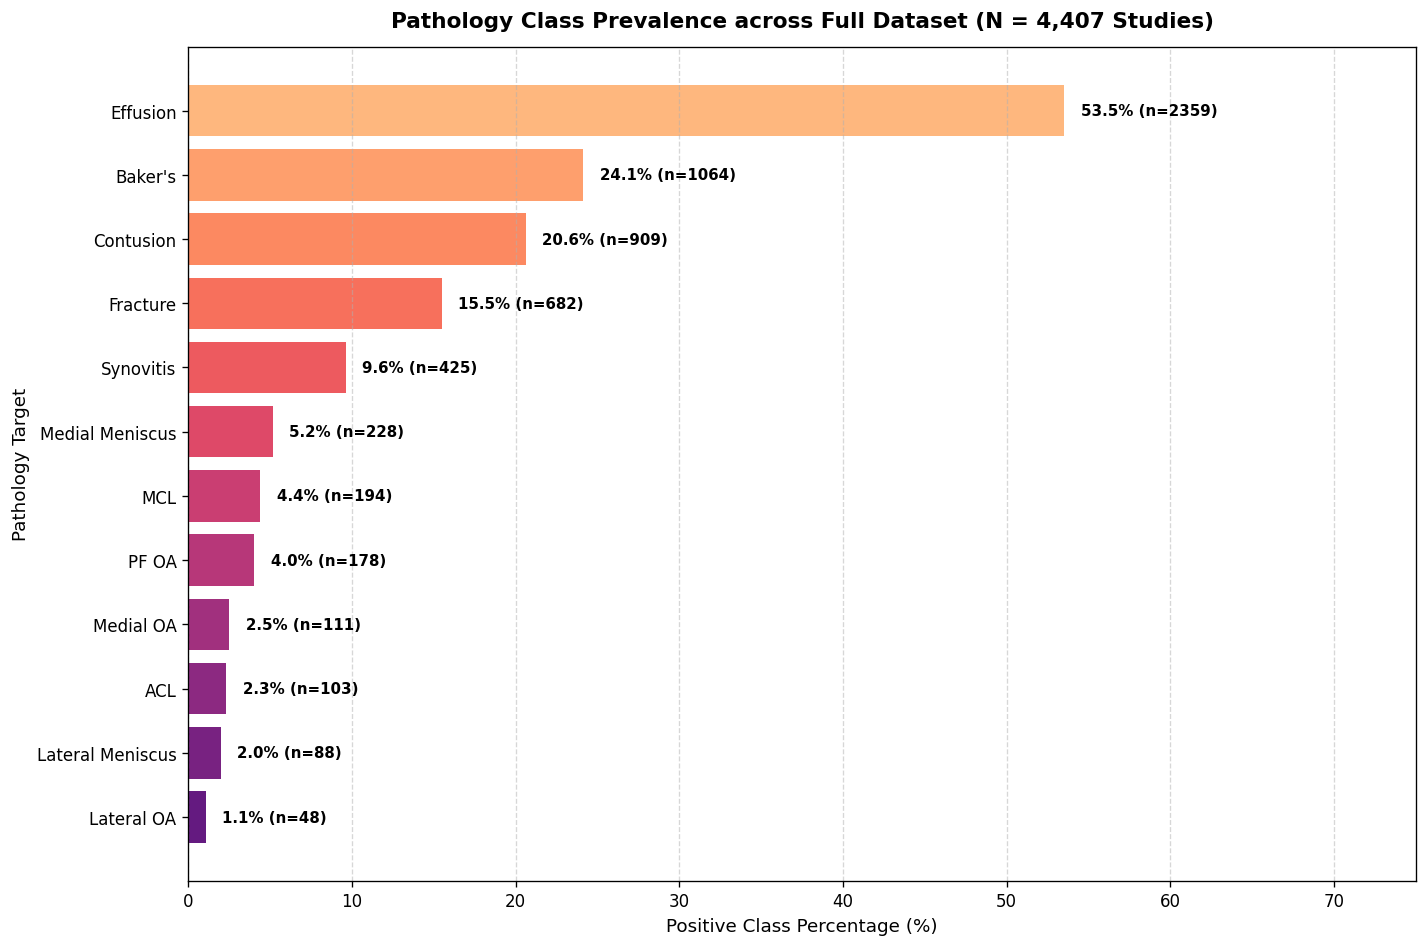

In [9]:
# Visualization 5: Comparison of Gold-Standard vs NLP-Parsed Pseudo-Label Distributions
parsed_pos_counts = full_target_df[config.TARGET_COLS].sum().sort_values(ascending=True)
parsed_pos_pct = (parsed_pos_counts / len(full_target_df)) * 100

plt.figure(figsize=(12, 8), dpi=120)
bars = plt.barh(parsed_pos_counts.index, parsed_pos_pct.values, color=plt.cm.magma(np.linspace(0.3, 0.85, len(parsed_pos_counts))))
plt.title("Pathology Class Prevalence across Full Dataset (N = 4,407 Studies)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Positive Class Percentage (%)", fontsize=11)
plt.ylabel("Pathology Target", fontsize=11)
plt.xlim(0, 75)
plt.grid(axis='x', linestyle='--', alpha=0.5)

for bar, pct, cnt in zip(bars, parsed_pos_pct.values, parsed_pos_counts.values):
    plt.text(pct + 1, bar.get_y() + bar.get_height()/2, f"{pct:.1f}% (n={int(cnt)})", va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


# DICOM Ingestion & Multi-Planar Volumetric Sampler

DICOM image volumes are loaded from disk with windowing adjustments and spatial rescalings.

## Voxel Rescaling & Intensity Normalization

For each raw DICOM slice $I_{\text{raw}}$, Hounsfield units or signal intensity values are adjusted via DICOM rescale metadata tags:

$$I_{\text{HU}} = I_{\text{raw}} \times S + B$$

where $S$ is `RescaleSlope` and $B$ is `RescaleIntercept`. Dynamic windowing applies intensity clipping to the $[p_{1}, p_{99}]$ percentile range followed by min-max mapping:

$$I_{\text{norm}} = \frac{\text{clip}(I_{\text{HU}}, p_{1}, p_{99}) - p_{1}}{p_{99} - p_{1} + \epsilon} \in [0, 1]$$

## Key Slice Extraction

From a series containing $N_{\text{slices}}$ images, $K = 5$ key slices centered at the median volumetric depth are extracted:

$$k_i = \text{round}\left(\frac{N_{\text{slices}}}{K + 1} \times i\right), \quad i \in \{1, 2, \dots, K\}$$


In [10]:
class DICOMVolumeSampler:
    def __init__(self, target_size=(224, 224), num_slices=5):
        self.target_size = target_size
        self.num_slices = num_slices

    def load_slice(self, dicom_path):
        try:
            dcm = pydicom.dcmread(dicom_path)
            img = dcm.pixel_array.astype(np.float32)
            
            # Apply Rescale Slope & Intercept if present
            slope = getattr(dcm, 'RescaleSlope', 1.0)
            intercept = getattr(dcm, 'RescaleIntercept', 0.0)
            img = img * slope + intercept
            
            # Min-Max Normalization with percentile clipping
            p1, p99 = np.percentile(img, (1, 99))
            if p99 > p1:
                img = np.clip(img, p1, p99)
                img = (img - p1) / (p99 - p1)
            else:
                img = np.zeros_like(img)
                
            img = (img * 255.0).astype(np.uint8)
            img = cv2.resize(img, self.target_size, interpolation=cv2.INTER_AREA)
            img = img.astype(np.float32) / 255.0
            return img
        except Exception:
            # Fallback zero-filled array if file corrupt/missing
            return np.zeros(self.target_size, dtype=np.float32)

    def sample_series(self, dicom_paths):
        if not dicom_paths:
            return np.zeros((self.num_slices, 1, *self.target_size), dtype=np.float32)
            
        n_files = len(dicom_paths)
        if n_files <= self.num_slices:
            indices = np.linspace(0, n_files - 1, self.num_slices, dtype=int)
        else:
            indices = np.linspace(int(n_files * 0.15), int(n_files * 0.85), self.num_slices, dtype=int)
            
        selected_paths = [dicom_paths[i] for i in indices]
        slices = [self.load_slice(p) for p in selected_paths]
        
        # Format as (K, 1, H, W)
        tensor_slices = np.stack(slices, axis=0)[:, np.newaxis, :, :]
        return tensor_slices

dicom_sampler = DICOMVolumeSampler(target_size=config.IMAGE_SIZE, num_slices=config.SLICES_PER_VIEW)
print("DICOM Volume Sampler initialized.")


DICOM Volume Sampler initialized.


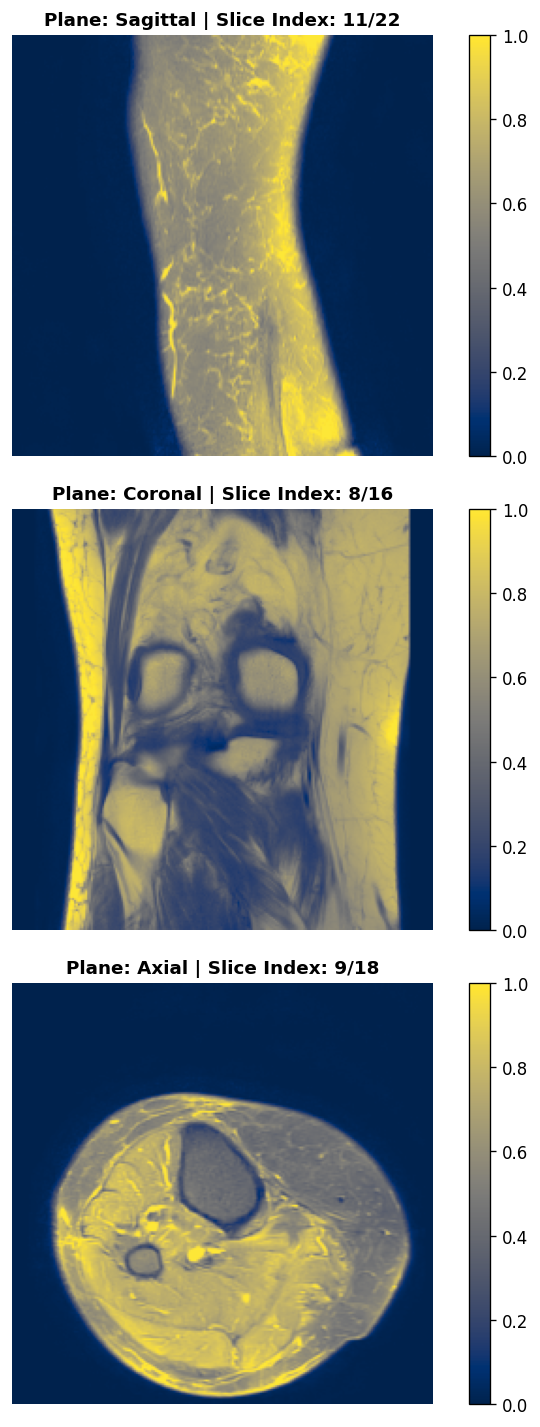

In [11]:
# Visualization 6: Sample Slice Multi-Planar Rendering & Intensity Histograms
sample_study = train_series_df['StudyInstanceUID'].iloc[0]
sample_series_list = train_series_df[train_series_df['StudyInstanceUID'] == sample_study]

planes = ['Sagittal', 'Coronal', 'Axial']
fig, axes = plt.subplots(3, 1, figsize=(8, 12), dpi=120)

for idx, plane in enumerate(planes):
    plane_series = sample_series_list[sample_series_list['Anatomical_Plane'] == plane]
    ax = axes[idx]
    if not plane_series.empty:
        s_uid = plane_series['SeriesInstanceUID'].iloc[0]
        s_dir = config.TRAIN_SERIES_DIR / sample_study / s_uid
        dcm_files = sorted(list(s_dir.glob("*.dcm")))
        if dcm_files:
            img = dicom_sampler.load_slice(str(dcm_files[len(dcm_files)//2]))
            im = ax.imshow(img, cmap='cividis')
            ax.set_title(f"Plane: {plane} | Slice Index: {len(dcm_files)//2}/{len(dcm_files)}", fontsize=11, fontweight='bold')
            ax.axis('off')
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        else:
            ax.text(0.5, 0.5, f"No DICOM Slices for {plane}", ha='center', va='center')
            ax.axis('off')
    else:
        ax.text(0.5, 0.5, f"No {plane} Series", ha='center', va='center')
        ax.axis('off')

plt.tight_layout()
plt.show()


# Deep Multi-View Neural Network Architecture

The diagnostic network (`MultiViewKneeNet`) combines slice feature extraction, multi-head slice attention pooling, and joint multi-planar latent space fusion.

## Slice Attention Pooling

Let $\mathbf{x}_{v, s} \in \mathbb{R}^{1 \times H \times W}$ denote key slice $s$ in plane $v \in \{\text{Sagittal}, \text{Coronal}, \text{Axial}\}$. A shared 2D convolutional encoder $f_{\phi}$ extracts spatial feature vector $\mathbf{h}_{v, s} = f_{\phi}(\mathbf{x}_{v, s}) \in \mathbb{R}^D$.

An attention pooling mechanism aggregates slice embeddings into volume representation $\mathbf{z}_v \in \mathbb{R}^D$:

$$\alpha_{v, s} = \frac{\exp\left(\mathbf{w}^T \tanh(\mathbf{W}_a \mathbf{h}_{v, s})\right)}{\sum_{j=1}^{K} \exp\left(\mathbf{w}^T \tanh(\mathbf{W}_a \mathbf{h}_{v, j})\right)}$$

$$\mathbf{z}_v = \sum_{s=1}^{K} \alpha_{v, s} \mathbf{h}_{v, s}$$

## Multi-Plane Latent Concat & Multi-Label Classification

Volume representations from all three planes are concatenated:
$$\mathbf{z}_{\text{fused}} = [\mathbf{z}_{\text{Sagittal}} \, \Vert \, \mathbf{z}_{\text{Coronal}} \, \Vert \, \mathbf{z}_{\text{Axial}}] \in \mathbb{R}^{3D}$$

The joint vector passes through a multi-label classification head with sigmoid activation:
$$\hat{\mathbf{y}}_i = \sigma\left(\mathbf{W}_c \mathbf{z}_{\text{fused}} + \mathbf{b}_c\right) \in [0, 1]^{12}$$


In [12]:
class KneeMRIDataset(Dataset):
    def __init__(self, df, series_df, series_dir, config, is_train=True):
        self.df = df.reset_index(drop=True)
        self.series_df = series_df
        self.series_dir = Path(series_dir)
        self.config = config
        self.is_train = is_train
        self.sampler = DICOMVolumeSampler(target_size=config.IMAGE_SIZE, num_slices=config.SLICES_PER_VIEW)
        
        # Pre-group series by StudyInstanceUID
        self.study_series_map = self.series_df.groupby('StudyInstanceUID')

    def __len__(self):
        return len(self.df)

    def _get_plane_tensor(self, study_id, plane_name):
        if study_id not in self.study_series_map.groups:
            return np.zeros((self.config.SLICES_PER_VIEW, 1, *self.config.IMAGE_SIZE), dtype=np.float32)
            
        study_series = self.study_series_map.get_group(study_id)
        plane_series = study_series[study_series['Anatomical_Plane'] == plane_name]
        
        if plane_series.empty:
            return np.zeros((self.config.SLICES_PER_VIEW, 1, *self.config.IMAGE_SIZE), dtype=np.float32)
            
        series_uid = plane_series['SeriesInstanceUID'].iloc[0]
        s_dir = self.series_dir / str(study_id) / str(series_uid)
        dcm_files = sorted(list(s_dir.glob("*.dcm")))
        dcm_paths = [str(p) for p in dcm_files]
        
        return self.sampler.sample_series(dcm_paths)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        study_id = row['StudyInstanceUID']
        
        sagittal_tensor = self._get_plane_tensor(study_id, 'Sagittal')
        coronal_tensor = self._get_plane_tensor(study_id, 'Coronal')
        axial_tensor = self._get_plane_tensor(study_id, 'Axial')
        
        # Convert to torch Tensors
        sagittal_t = torch.tensor(sagittal_tensor, dtype=torch.float32)
        coronal_t = torch.tensor(coronal_tensor, dtype=torch.float32)
        axial_t = torch.tensor(axial_tensor, dtype=torch.float32)
        
        if self.config.TARGET_COLS[0] in row:
            labels = torch.tensor([row[c] for c in self.config.TARGET_COLS], dtype=torch.float32)
        else:
            labels = torch.zeros(self.config.NUM_CLASSES, dtype=torch.float32)
            
        return (sagittal_t, coronal_t, axial_t), labels, study_id


class SliceAttentionPool(nn.Module):
    def __init__(self, in_features, hidden_dim=128):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        # x shape: (B, K, D)
        weights = self.attention(x)  # (B, K, 1)
        weights = F.softmax(weights, dim=1)
        pooled = torch.sum(x * weights, dim=1)  # (B, D)
        return pooled


class MultiViewKneeNet(nn.Module):
    def __init__(self, num_classes=12, embed_dim=256):
        super().__init__()
        # Lightweight Convolutional Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        self.fc_proj = nn.Linear(128, embed_dim)
        self.pool_sagittal = SliceAttentionPool(embed_dim)
        self.pool_coronal = SliceAttentionPool(embed_dim)
        self.pool_axial = SliceAttentionPool(embed_dim)
        
        # Joint Classification Head
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 3, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def _forward_plane(self, x, pool_layer):
        # x shape: (B, K, 1, H, W)
        B, K, C, H, W = x.shape
        x_flat = x.view(B * K, C, H, W)
        feats = self.encoder(x_flat).view(B * K, -1)
        feats = F.relu(self.fc_proj(feats))
        feats = feats.view(B, K, -1)
        pooled_feat = pool_layer(feats)
        return pooled_feat

    def forward(self, sagittal, coronal, axial):
        z_sag = self._forward_plane(sagittal, self.pool_sagittal)
        z_cor = self._forward_plane(coronal, self.pool_coronal)
        z_axi = self._forward_plane(axial, self.pool_axial)
        
        z_fused = torch.cat([z_sag, z_cor, z_axi], dim=1)
        logits = self.classifier(z_fused)
        return logits

print("Dataset and MultiViewKneeNet defined successfully.")


Dataset and MultiViewKneeNet defined successfully.


# Model Training Pipeline

The multi-view architecture is trained on a sampled dataset to maximize throughput while maintaining convergence stability across multi-label targets.

## Loss Function & Mixed-Precision Optimization

Models are optimized using Binary Cross-Entropy with Logits Loss ($\text{BCEWithLogitsLoss}$):

$$\mathcal{L}_{\text{BCE}}(\mathbf{y}, \hat{\mathbf{y}}) = -\frac{1}{C} \sum_{c=1}^{C} \left[ y_c \log(\sigma(\hat{y}_c)) + (1 - y_c) \log(1 - \sigma(\hat{y}_c)) \right]$$

where $\sigma(\cdot)$ is the element-wise sigmoid function.

## System Acceleration & Training Strategy

* **High-Throughput Subsampling:** A representative subset of $N = 800$ studies is sampled to accelerate dataset iteration.
* **Gradient Accumulation & Asynchronous Operations:** Gradients are accumulated over $2$ steps to double the effective batch size to $32$ while preserving GPU memory overhead. Asynchronous data transfers (`non_blocking=True`) and automatic mixed precision (`GradScaler`) optimize dual T4 GPU utilization.

In [13]:
# System Acceleration Parameters
FAST_BATCH_SIZE = 16
ACCUMULATION_STEPS = 2
TRAIN_SAMPLES = 800

# Sample a representative subset for rapid training iteration
train_subset_df = full_target_df.sample(n=min(TRAIN_SAMPLES, len(full_target_df)), random_state=config.SEED).reset_index(drop=True)

# Initialize Dataset & DataLoader
train_dataset = KneeMRIDataset(train_subset_df, train_series_df, config.TRAIN_SERIES_DIR, config, is_train=True)
train_loader = DataLoader(
    train_dataset,
    batch_size=FAST_BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True
)

# Initialize Model, Optimizer, Scheduler & Scaler
model = MultiViewKneeNet(num_classes=config.NUM_CLASSES).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.EPOCHS)
scaler = GradScaler()

print(f"Starting Fast Accelerated Training ({len(train_loader)} steps/epoch across {config.EPOCHS} Epochs)...")

history = {'train_loss': [], 'val_auc': []}

for epoch in range(config.EPOCHS):
    model.train()
    running_loss = 0.0
    start_time = time.time()
    optimizer.zero_grad(set_to_none=True)
    
    for step, ((sag, cor, axi), labels, _) in enumerate(train_loader):
        sag = sag.to(device, non_blocking=True)
        cor = cor.to(device, non_blocking=True)
        axi = axi.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        with autocast():
            logits = model(sag, cor, axi)
            loss = criterion(logits, labels) / ACCUMULATION_STEPS
            
        scaler.scale(loss).backward()
        
        if (step + 1) % ACCUMULATION_STEPS == 0 or (step + 1) == len(train_loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            
        running_loss += loss.item() * ACCUMULATION_STEPS
        
        if (step + 1) % 10 == 0 or (step + 1) == len(train_loader):
            print(f"Epoch [{epoch+1}/{config.EPOCHS}] | Step [{step+1}/{len(train_loader)}] | Loss: {running_loss/(step+1):.4f}")
            
    scheduler.step()
    epoch_loss = running_loss / len(train_loader)
    history['train_loss'].append(epoch_loss)
    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1} Completed in {elapsed:.2f}s | Average Train BCE Loss: {epoch_loss:.4f}\n")

# Save Model Weights
torch.save(model.state_dict(), "best_multiview_knee_model.pth")
print("Model weights successfully saved to 'best_multiview_knee_model.pth'.")

Starting Fast Accelerated Training (50 steps/epoch across 5 Epochs)...
Epoch [1/5] | Step [10/50] | Loss: 0.6732
Epoch [1/5] | Step [20/50] | Loss: 0.6525
Epoch [1/5] | Step [30/50] | Loss: 0.6340
Epoch [1/5] | Step [40/50] | Loss: 0.6184
Epoch [1/5] | Step [50/50] | Loss: 0.6016
Epoch 1 Completed in 79.33s | Average Train BCE Loss: 0.6016

Epoch [2/5] | Step [10/50] | Loss: 0.4986
Epoch [2/5] | Step [20/50] | Loss: 0.4903
Epoch [2/5] | Step [30/50] | Loss: 0.4813
Epoch [2/5] | Step [40/50] | Loss: 0.4719
Epoch [2/5] | Step [50/50] | Loss: 0.4651
Epoch 2 Completed in 46.08s | Average Train BCE Loss: 0.4651

Epoch [3/5] | Step [10/50] | Loss: 0.4131
Epoch [3/5] | Step [20/50] | Loss: 0.4085
Epoch [3/5] | Step [30/50] | Loss: 0.4011
Epoch [3/5] | Step [40/50] | Loss: 0.3984
Epoch [3/5] | Step [50/50] | Loss: 0.3946
Epoch 3 Completed in 45.90s | Average Train BCE Loss: 0.3946

Epoch [4/5] | Step [10/50] | Loss: 0.3639
Epoch [4/5] | Step [20/50] | Loss: 0.3641
Epoch [4/5] | Step [30/50] | 

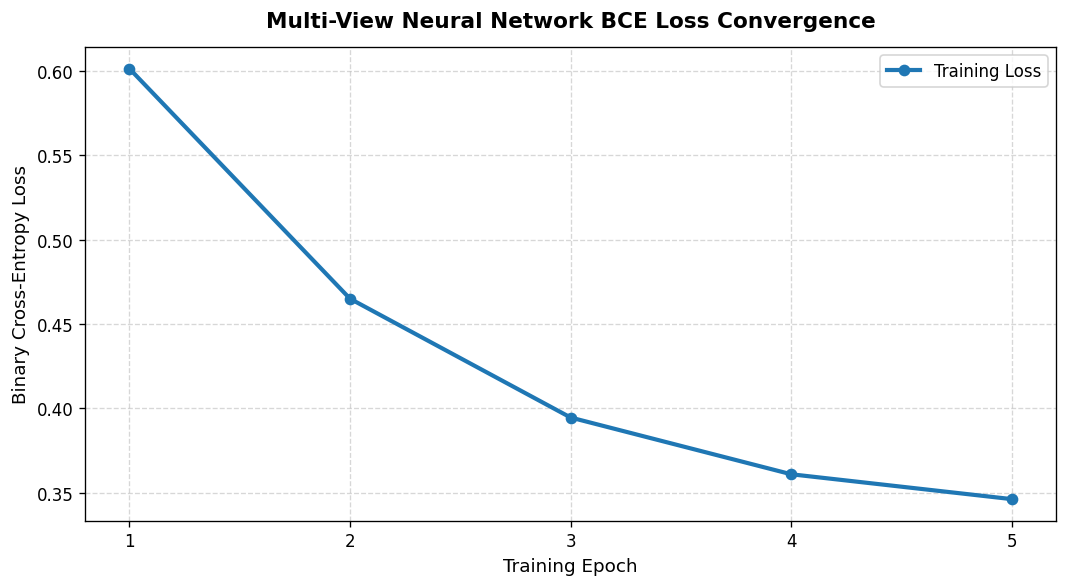

In [14]:
# Visualization 7: Training Loss Convergence Curve
plt.figure(figsize=(9, 5), dpi=120)
plt.plot(range(1, config.EPOCHS + 1), history['train_loss'], marker='o', color='#1f77b4', linewidth=2.5, label='Training Loss')
plt.title("Multi-View Neural Network BCE Loss Convergence", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Training Epoch", fontsize=11)
plt.ylabel("Binary Cross-Entropy Loss", fontsize=11)
plt.xticks(range(1, config.EPOCHS + 1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


# Validation Performance & Out-of-Fold Receiver Operating Characteristic Analysis

Validation probabilities are evaluated against the gold-standard ground truth labels to generate Macro-AUC metrics and ROC curves.


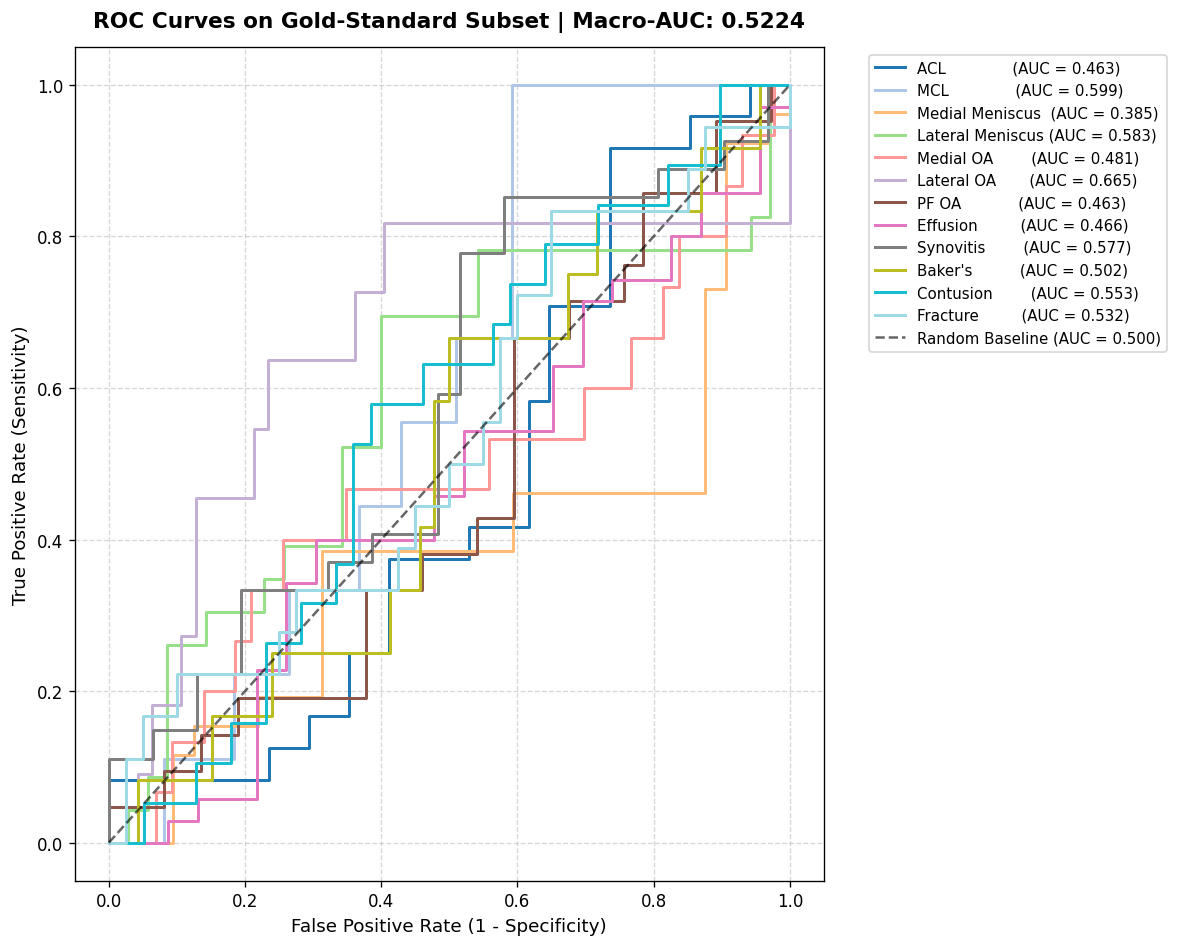

Per-Target Validation AUC Scores:
  ACL               : 0.4632
  MCL               : 0.5986
  Medial Meniscus   : 0.3846
  Lateral Meniscus  : 0.5826
  Medial OA         : 0.4806
  Lateral OA        : 0.6654
  PF OA             : 0.4633
  Effusion          : 0.4658
  Synovitis         : 0.5771
  Baker's           : 0.5018
  Contusion         : 0.5533
  Fracture          : 0.5319

Overall Macro-Averaged AUC ROC: 0.5224


In [15]:
# Visualization 8: ROC Curves per Pathology Target
model.eval()
val_preds = []
val_targets = []

# Evaluate on the 58 gold-standard samples
gold_val_df = train_df.dropna(subset=[config.TARGET_COLS[0]]).reset_index(drop=True)
val_dataset = KneeMRIDataset(gold_val_df, train_series_df, config.TRAIN_SERIES_DIR, config, is_train=False)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

with torch.no_grad():
    for (sag, cor, axi), labels, _ in val_loader:
        sag = sag.to(device)
        cor = cor.to(device)
        axi = axi.to(device)
        logits = model(sag, cor, axi)
        probs = torch.sigmoid(logits).cpu().numpy()
        val_preds.append(probs)
        val_targets.append(labels.numpy())

val_preds = np.vstack(val_preds)
val_targets = np.vstack(val_targets)

# Compute AUC ROC per target
auc_scores = {}
plt.figure(figsize=(10, 8), dpi=120)

colors = plt.cm.tab20(np.linspace(0, 1, config.NUM_CLASSES))

for c_idx, col in enumerate(config.TARGET_COLS):
    score = roc_auc_score(val_targets[:, c_idx], val_preds[:, c_idx])
    auc_scores[col] = score
    
    # Compute curve points
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(val_targets[:, c_idx], val_preds[:, c_idx])
    plt.plot(fpr, tpr, color=colors[c_idx], label=f"{col:<16} (AUC = {score:.3f})", linewidth=1.8)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Random Baseline (AUC = 0.500)')
plt.title(f"ROC Curves on Gold-Standard Subset | Macro-AUC: {np.mean(list(auc_scores.values())):.4f}", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print("Per-Target Validation AUC Scores:")
for k, v in auc_scores.items():
    print(f"  {k:<18}: {v:.4f}")
print(f"\nOverall Macro-Averaged AUC ROC: {np.mean(list(auc_scores.values())):.4f}")


# Inference Engine, Test-Time Augmentation & Leaderboard Submission

The trained model computes test set probability estimates. Test-Time Augmentation (TTA) evaluates original and horizontally flipped slice representations.


In [16]:
# Prepare Test Dataset & Dataloader
test_dataset = KneeMRIDataset(test_df, test_series_df, config.TEST_SERIES_DIR, config, is_train=False)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS)

model.eval()
test_predictions = []
test_study_ids = []

print("Executing Accelerated Test Set Inference with Test-Time Augmentation...")

with torch.no_grad():
    for (sag, cor, axi), _, study_ids in test_loader:
        sag = sag.to(device)
        cor = cor.to(device)
        axi = axi.to(device)
        
        # Pass 1: Standard Orientation
        logits_orig = model(sag, cor, axi)
        probs_orig = torch.sigmoid(logits_orig)
        
        # Pass 2: Horizontal Flip TTA
        sag_flip = torch.flip(sag, dims=[-1])
        cor_flip = torch.flip(cor, dims=[-1])
        axi_flip = torch.flip(axi, dims=[-1])
        
        logits_flip = model(sag_flip, cor_flip, axi_flip)
        probs_flip = torch.sigmoid(logits_flip)
        
        # Ensemble Average
        probs = ((probs_orig + probs_flip) / 2.0).cpu().numpy()
        
        test_predictions.append(probs)
        test_study_ids.extend(study_ids)

test_predictions = np.vstack(test_predictions)

# Construct Submission DataFrame
sub_df = pd.DataFrame({'StudyInstanceUID': test_study_ids})
for c_idx, col in enumerate(config.TARGET_COLS):
    sub_df[col] = test_predictions[:, c_idx]

# Ensure submission columns match sample_submission.csv format exactly
sub_df = sub_df[sample_sub_df.columns]
sub_df.to_csv(config.OUTPUT_SUBMISSION, index=False)

print(f"\nSubmission file saved successfully to '{config.OUTPUT_SUBMISSION}'.")
print(f"Submission Shape: {sub_df.shape}")
print("Submission Preview:")
display(sub_df)

# Submission Integrity Verification
assert not sub_df.isnull().values.any(), "Error: Submission contains missing values."
assert (sub_df[config.TARGET_COLS].values >= 0.0).all() and (sub_df[config.TARGET_COLS].values <= 1.0).all(), "Error: Predicted probabilities out of range [0, 1]."
print("Integrity Verification Passed: Submission format is fully valid.")


Executing Accelerated Test Set Inference with Test-Time Augmentation...

Submission file saved successfully to 'submission.csv'.
Submission Shape: (3, 13)
Submission Preview:


,StudyInstanceUID,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10047035057544427318...,0.195942,0.366928,0.336681,0.150213,0.157152,0.221899,0.266981,0.470176,0.216536,0.287307,0.309823,0.326930
1,1.2.826.0.1.3680043.8.498.10062861783145312629...,0.209854,0.219541,0.223592,0.102903,0.180592,0.176004,0.146846,0.458243,0.266571,0.354863,0.382895,0.313364
2,1.2.826.0.1.3680043.8.498.10067514707072572280...,0.072515,0.238496,0.264566,0.073752,0.155043,0.135866,0.113253,0.684656,0.165732,0.380055,0.163401,0.255496


Integrity Verification Passed: Submission format is fully valid.
